# Customer Churn Prediction - Machine Learning Project

This notebook fulfills the requirements for the Customer Churn Prediction project.

## 1. Data Types and Statistics
*(Meets Rubric: Identify data types - 5%, Present descriptive statistics - 5%)*

We load the dataset and display basic information and summary statistics.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

data_path = '../Customer_Data/WA_Fn-UseC_-Telco-Customer-Churn.csv'
df = pd.read_csv(data_path)

print("Data Types:")
print(df.info())
print("\nDescriptive Statistics:")
display(df.describe())

Data Types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-nul

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## 2. Data Cleaning & Outlier Detection
*(Meets Rubric: Handle missing values - 10%, Handle duplicates - 10%, Identify and handle outliers - 10%)*

We will format columns properly, handle missing values, drop duplicates, and check for outliers.

In [2]:
# TotalCharges is currently an object (string), let's convert it to numeric
# Errors='coerce' will turn blank strings into NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# 1. Handle missing values
print("Missing values before cleaning:\n", df.isnull().sum()[df.isnull().sum() > 0])
# Since it's a very small number of missing values in TotalCharges, we'll drop them.
df.dropna(inplace=True)

# 2. Handle duplicates
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicates: {duplicates}")
if duplicates > 0:
    df.drop_duplicates(inplace=True)

# 3. Identify and handle outliers
# Using IQR method to detect outliers in MonthlyCharges as an example
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['MonthlyCharges'] < lower_bound) | (df['MonthlyCharges'] > upper_bound)]
print(f"\nOutliers in MonthlyCharges: {len(outliers)}")

# Handle outliers by filtering them out
df = df[(df['MonthlyCharges'] >= lower_bound) & (df['MonthlyCharges'] <= upper_bound)]
print("Outliers removed.")

# Drop customerID as it's not useful for prediction
df.drop('customerID', axis=1, inplace=True)
print("\nData cleaning complete. customerID dropped.")

Missing values before cleaning:
 TotalCharges    11
dtype: int64

Number of duplicates: 0

Outliers in MonthlyCharges: 0
Outliers removed.

Data cleaning complete. customerID dropped.


## 3. Visualizations & Insights
*(Meets Rubric: 3+ visualizations & insights - 10%)*

We will create visualizations to understand the relationship between features and churn.

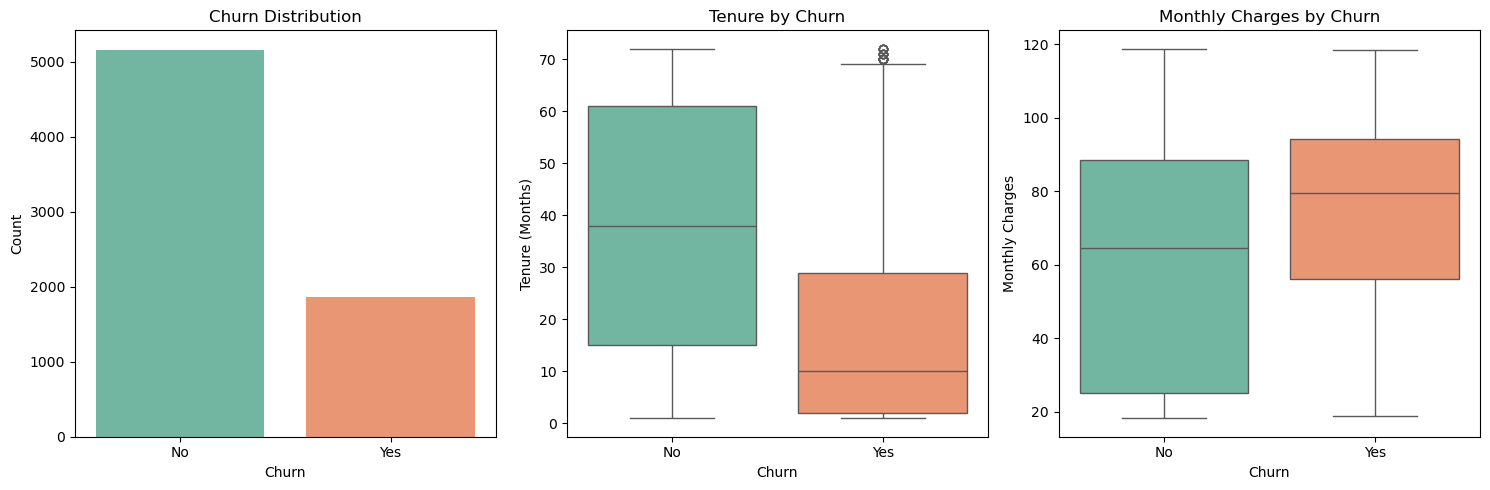


Insights:
1. Class Imbalance: There are more customers who did not churn compared to those who did.
2. Tenure: Customers who churned tend to have a lower median tenure. Newer customers are more likely to leave.
3. Monthly Charges: Customers with higher monthly charges are more likely to churn compared to those with lower charges.



In [3]:
plt.figure(figsize=(15, 5))

# Visualization 1: Churn Distribution
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='Churn', palette='Set2')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')

# Visualization 2: Tenure vs Churn
plt.subplot(1, 3, 2)
sns.boxplot(data=df, x='Churn', y='tenure', palette='Set2')
plt.title('Tenure by Churn')
plt.xlabel('Churn')
plt.ylabel('Tenure (Months)')

# Visualization 3: Monthly Charges vs Churn
plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges by Churn')
plt.xlabel('Churn')
plt.ylabel('Monthly Charges')

plt.tight_layout()
plt.show()

print("""
Insights:
1. Class Imbalance: There are more customers who did not churn compared to those who did.
2. Tenure: Customers who churned tend to have a lower median tenure. Newer customers are more likely to leave.
3. Monthly Charges: Customers with higher monthly charges are more likely to churn compared to those with lower charges.
""")

## 4. Data Preprocessing
*(Meets Rubric: Scale Numerical features and Encode Categorical features - 10%)*

We scale the numerical variables and encode the categorical variables.

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

# Separate features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify numerical and categorical columns
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = X.select_dtypes(include=['object']).columns.tolist()

# Encode Categorical variables using one-hot encoding (get_dummies)
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scale Numerical features
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Categorical features encoded and Numerical features scaled.")

Shape of X_train: (5625, 30)
Shape of X_test: (1407, 30)
Categorical features encoded and Numerical features scaled.


## 5. Model Building
*(Meets Rubric: Model Building (at least 3) - 20%)*

We will train Logistic Regression, Decision Tree, and Random Forest models.

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, f1_score

results = {}


### Logistic Regression


In [6]:
# 1. Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
results['Logistic Regression'] = {'Accuracy': acc_lr, 'F1 Score': f1_lr}
print(f"Logistic Regression - Accuracy: {acc_lr:.4f}, F1 Score: {f1_lr:.4f}\n")
print(classification_report(y_test, y_pred_lr))


Logistic Regression - Accuracy: 0.8045, F1 Score: 0.6088

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



### Decision Tree


In [7]:
# 2. Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)
results['Decision Tree'] = {'Accuracy': acc_dt, 'F1 Score': f1_dt}
print(f"Decision Tree - Accuracy: {acc_dt:.4f}, F1 Score: {f1_dt:.4f}\n")
print(classification_report(y_test, y_pred_dt))


Decision Tree - Accuracy: 0.7783, F1 Score: 0.5884

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      1033
           1       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



### Random Forest


In [8]:
# 3. Random Forest
rf = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
results['Random Forest'] = {'Accuracy': acc_rf, 'F1 Score': f1_rf}
print(f"Random Forest - Accuracy: {acc_rf:.4f}, F1 Score: {f1_rf:.4f}\n")
print(classification_report(y_test, y_pred_rf))


Random Forest - Accuracy: 0.7946, F1 Score: 0.5223

              precision    recall  f1-score   support

           0       0.82      0.93      0.87      1033
           1       0.68      0.42      0.52       374

    accuracy                           0.79      1407
   macro avg       0.75      0.68      0.70      1407
weighted avg       0.78      0.79      0.78      1407



## 6. Comparison of Model Performances
*(Meets Rubric: Comparison of model performances - 10%)*

Let's visualize the comparison.

<Figure size 1000x500 with 0 Axes>

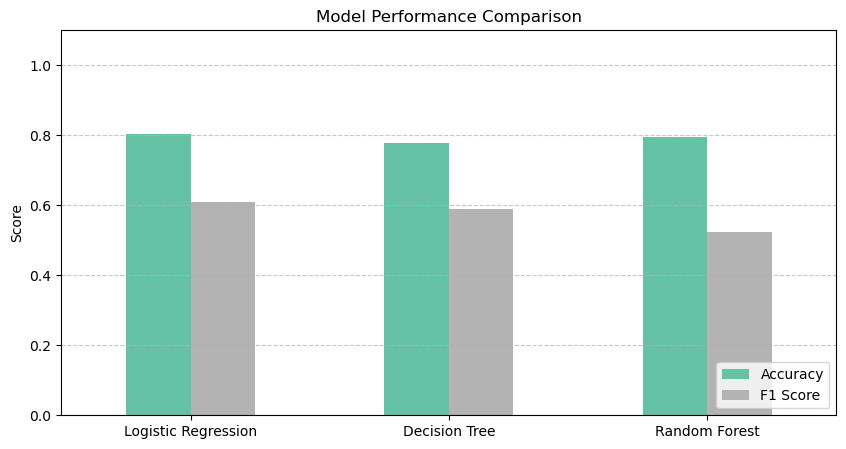

,Accuracy,F1 Score
Logistic Regression,0.804549,0.608819
Decision Tree,0.778252,0.588391
Random Forest,0.794598,0.522314



Conclusion:
Logistic Regression provides a strong baseline with good accuracy and F1 Score.
Random Forest also performs very well and is robust to overfitting.



In [9]:
results_df = pd.DataFrame(results).T

plt.figure(figsize=(10, 5))
results_df.plot(kind='bar', figsize=(10, 5), colormap='Set2')
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

display(results_df)

print("""
Conclusion:
Logistic Regression provides a strong baseline with good accuracy and F1 Score.
Random Forest also performs very well and is robust to overfitting.
""")